In [6]:
import pandas as pd
import matplotlib.pyplot as plt

In [46]:
ibm_data = pd.read_csv('ibm_profile_forreal.csv') 
csz_data = pd.read_csv('profile_points_export.csv')
csz_data = csz_data.drop(columns=['SAMPLE_1'])
csz_data = csz_data.rename(columns={'SAMPLE_1_2': 'Depth'})

In [47]:
display(csz_data)
display(ibm_data)

,id,distance,angle,Depth
0,2,0,346.723603,-657.043030
1,2,30,346.723603,-642.099365
2,2,60,346.723603,-624.522339
3,2,90,346.723603,-609.945496
4,2,120,346.723603,-613.508118
...,...,...,...,...
509,2,15270,346.723603,-383.404449
510,2,15300,346.723603,-381.689117
511,2,15330,346.723603,-379.833923
512,2,15360,346.723603,-379.833923


,id,distance,angle,Depth1
0,1,0,176.891969,-5715.013184
1,1,30,176.891969,-5719.430664
2,1,60,176.891969,-5719.430664
3,1,90,176.891969,-5722.964844
4,1,120,176.891969,-5722.964844
...,...,...,...,...
947,1,28410,176.891969,-5763.605957
948,1,28440,176.891969,-5763.605957
949,1,28470,176.891969,-5752.120605
950,1,28500,176.891969,-5752.120605


(0.0, 12000.0)

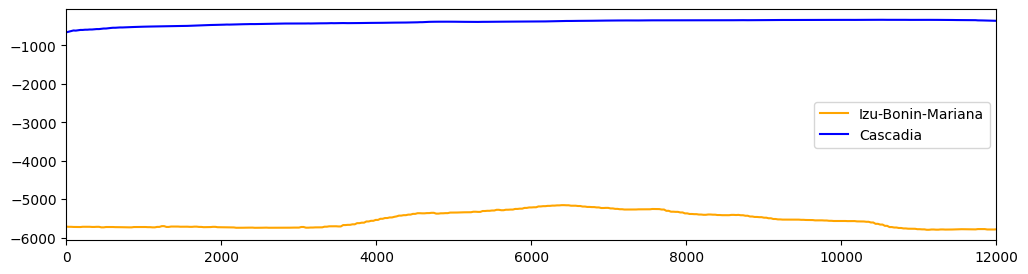

In [50]:
fig, ax = plt.subplots(figsize = (12,3))


plt.plot(ibm_data.distance, ibm_data.Depth1, c='orange', label = 'Izu-Bonin-Mariana')
plt.plot(csz_data.distance, csz_data.Depth, c='blue', label = 'Cascadia')
plt.legend()
plt.xlim(0,12000)

/tmp/ipykernel_4086321/908925601.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{abs(t):.0f}" for t in ax.get_yticks()])


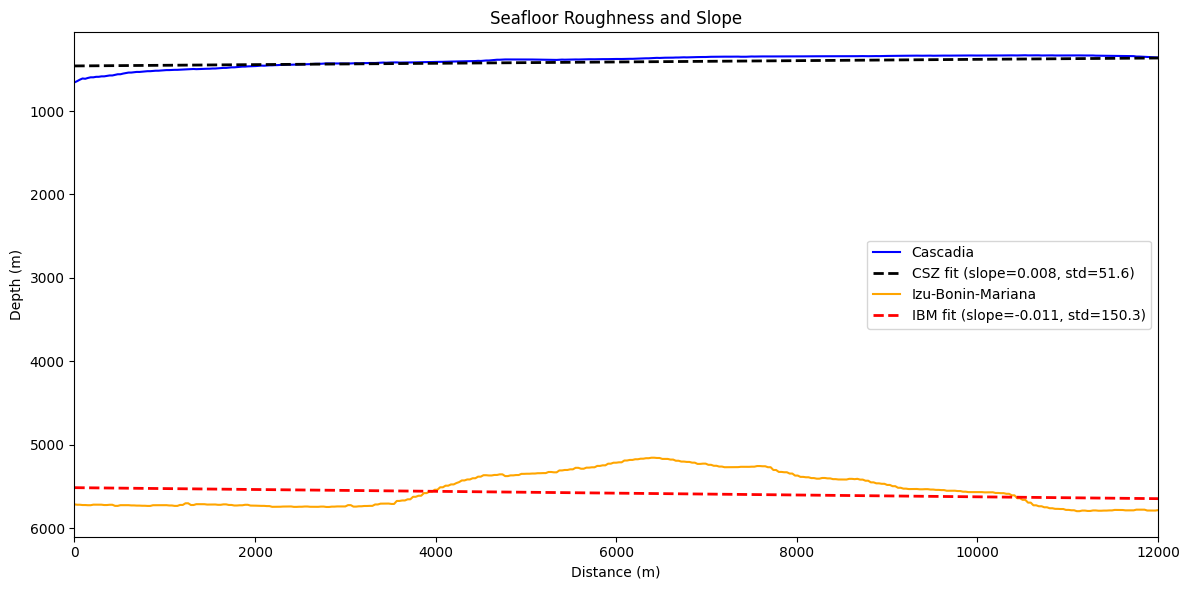

IBM: slope=-0.0110, std dev=150.2836
CSZ: slope=0.0079, std dev=51.5684


In [52]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12,6))

# --- Original data ---
x1 = ibm_data.distance.values
y1 = ibm_data.Depth1.values

x2 = csz_data.distance.values
y2 = csz_data.Depth.values

# --- Linear regression (IBM) ---
m1, b1 = np.polyfit(x1, y1, 1)
y1_fit = m1 * x1 + b1
resid1 = y1 - y1_fit
std1 = np.std(resid1)   # standard deviation of residuals

# --- Linear regression (CSZ) ---
m2, b2 = np.polyfit(x2, y2, 1)
y2_fit = m2 * x2 + b2
resid2 = y2 - y2_fit
std2 = np.std(resid2)


ax.plot(x2, y2, c='blue', label='Cascadia')
ax.plot(x2, y2_fit, 'k--', linewidth=2,
        label=f'CSZ fit (slope={m2:.3f}, std={std2:.1f})')
ax.plot(x1, y1, c='orange', label='Izu-Bonin-Mariana')
ax.plot(x1, y1_fit, 'r--', linewidth=2,
        label=f'IBM fit (slope={m1:.3f}, std={std1:.1f})')

# --- Formatting ---
ax.set_xlim(0, 12000)
ax.set_xlabel("Distance (m)")
ax.set_ylabel("Depth (m)")
ax.set_title("Seafloor Roughness and Slope")

# Remove negative signs from y-axis tick labels
ax.set_yticklabels([f"{abs(t):.0f}" for t in ax.get_yticks()])

ax.legend()
plt.tight_layout()
plt.show()

print(f"IBM: slope={m1:.4f}, std dev={std1:.4f}")
print(f"CSZ: slope={m2:.4f}, std dev={std2:.4f}")
